In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("เชื่อมต่อ Drive สำเร็จ!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
เชื่อมต่อ Drive สำเร็จ!


In [ ]:
!pip install -q pycocotools mediapipe opencv-python-headless tqdm
import cv2, mediapipe as mp, numpy as np
print("ติดตั้งเครื่องมือ MediaPipe และ OpenCV เรียบร้อย!")

ติดตั้งเครื่องมือ MediaPipe และ OpenCV เรียบร้อย!


In [ ]:
import os

# กำหนด Path หลักที่เคยสร้างไว้ใน Notebook แรก
BASE = '/content/drive/MyDrive/exercise_pose'
ANNO = f'{BASE}/data/coco/annotations'
IMGS = f'{BASE}/data/coco/images'
PROC = f'{BASE}/data/processed'

print(f"ระบบพร้อมทำงานที่โฟลเดอร์: {BASE}")

ระบบพร้อมทำงานที่โฟลเดอร์: /content/drive/MyDrive/exercise_pose


In [ ]:
from pycocotools.coco import COCO
import numpy as np

coco_instance = COCO(f'{ANNO}/person_keypoints_val2017.json') # Renamed to avoid conflict with class name
img_ids = coco_instance.getImgIds(catIds=coco_instance.getCatIds('person'))
ann_ids = coco_instance.getAnnIds(catIds=1, iscrowd=False)
anns = coco_instance.loadAnns(ann_ids)

print(f"รูปทั้งหมด: {len(img_ids):,}")
print(f"annotations: {len(anns):,}")
print(f"เฉลี่ยคน/รูป: {len(anns)/len(img_ids):.1f}")

loading annotations into memory...
Done (t=0.54s)
creating index...
index created!
รูปทั้งหมด: 2,693
annotations: 10,777
เฉลี่ยคน/รูป: 4.0


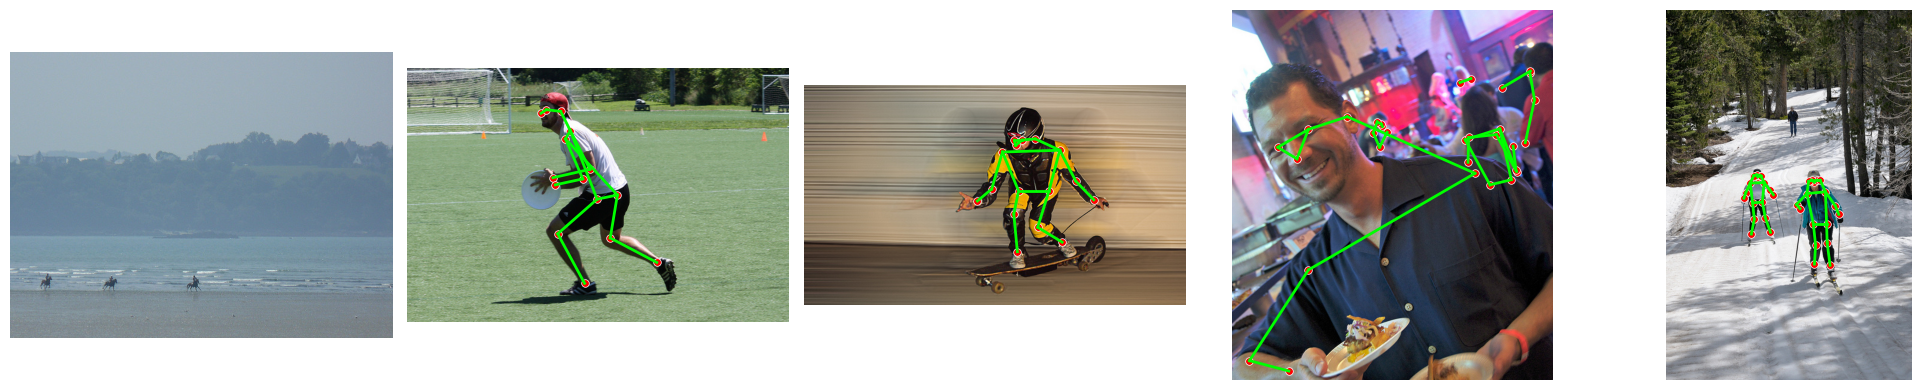

In [ ]:
#ดู 5 รูปแรก เพื่อเข้าใจว่า keypoints วางอยู่ถูกต้องไหม
import matplotlib.pyplot as plt
from PIL import Image
import random
import os # Required for os.makedirs
import numpy as np # Required for numpy operations

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
sample_ids = random.sample(img_ids, 5)

# Get category info for 'person' to extract skeleton definition
person_cat_id = coco_instance.getCatIds(catNms=['person'])[0]
person_cat_info = coco_instance.loadCats([person_cat_id])[0]
skeleton = person_cat_info['skeleton']

for ax, img_id in zip(axes, sample_ids):
    img_info = coco_instance.loadImgs(img_id)[0]
    img = Image.open(f"{IMGS}/val2017/{img_info["file_name"]}")
    ann_ids = coco_instance.getAnnIds(imgIds=img_id, catIds=1)
    anns = coco_instance.loadAnns(ann_ids)
    ax.imshow(img)

    # Manually draw keypoints and skeleton
    for ann in anns:
        if 'keypoints' in ann:
            s = ann['keypoints']
            # Convert to (x,y,v) format where v is visibility
            x = np.array(s[0::3])
            y = np.array(s[1::3])
            v = np.array(s[2::3])

            # Draw keypoints
            ax.scatter(x[v > 0], y[v > 0], s=30, c='red', marker='o', edgecolors='white', linewidths=0.5)

            # Draw skeleton connections
            for sk_id in skeleton:
                p1_idx = sk_id[0] - 1 # COCO keypoint indices are 1-based
                p2_idx = sk_id[1] - 1

                if v[p1_idx] > 0 and v[p2_idx] > 0:
                    ax.plot([x[p1_idx], x[p2_idx]], [y[p1_idx], y[p2_idx]], linewidth=2, color='lime')

    ax.axis('off')

plt.tight_layout()

# Create the output directory if it doesn't exist
os.makedirs(f"{BASE}/outputs", exist_ok=True)

plt.savefig(f"{BASE}/outputs/explore_sample.png")
plt.show()

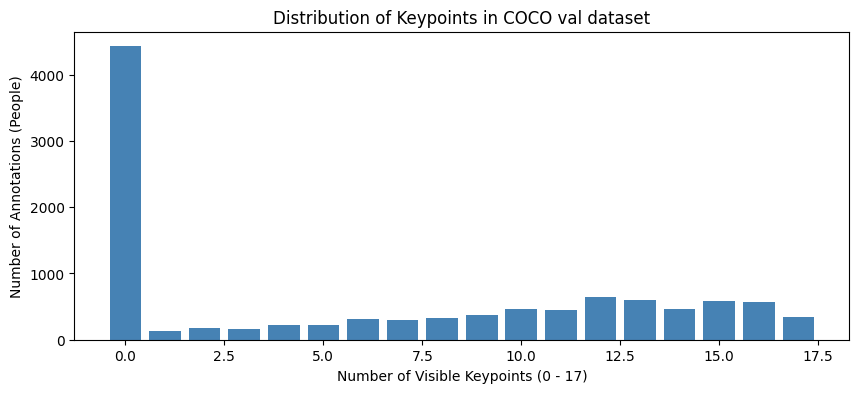

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# ใช้ coco_instance แทน coco ตามที่เราเคยตั้งค่าไว้
kp_counts = Counter(a['num_keypoints'] for a in coco_instance.loadAnns(
    coco_instance.getAnnIds(catIds=1, iscrowd=False)))

plt.figure(figsize=(10, 4))
plt.bar(kp_counts.keys(), kp_counts.values(), color='steelblue')

# เปลี่ยนชื่อแกนและหัวกราฟเป็นภาษาอังกฤษเพื่อแก้ปัญหาตัวอักษรสี่เหลี่ยม
plt.xlabel('Number of Visible Keypoints (0 - 17)')
plt.ylabel('Number of Annotations (People)')
plt.title('Distribution of Keypoints in COCO val dataset')

# plt.savefig(f'{BASE}/outputs/kp_distribution.png') # คอมเมนต์ไว้ก่อนเผื่อระบบคุณยังไม่ได้สร้างโฟลเดอร์ outputs
plt.show()

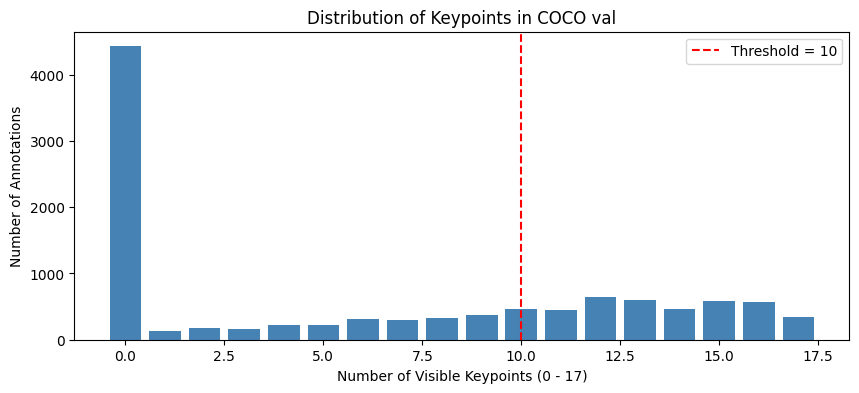

--- ผลลัพธ์การคัดกรองข้อมูล ---
ข้อมูลคนทั้งหมดตอนแรก:              10,777 คน
ข้อมูลคุณภาพสูง (>= 10 จุด): 4,116 คน
ข้อมูลขยะที่ถูกตัดทิ้ง:              6,661 คน
เหลือ:                               38.2%

เซฟแล้ว → /content/drive/MyDrive/exercise_pose/data/processed/good_anns_val.pkl


In [ ]:
# ── 1. กราฟ Distribution (ภาษาอังกฤษ แก้ปัญหาฟอนต์) ──────────────
plt.figure(figsize=(10, 4))
plt.bar(kp_counts.keys(), kp_counts.values(), color='steelblue')
plt.xlabel('Number of Visible Keypoints (0 - 17)')
plt.ylabel('Number of Annotations')
plt.title('Distribution of Keypoints in COCO val')
plt.axvline(x=10, color='red', linestyle='--', label='Threshold = 10')  # เพิ่ม: เส้นแสดง threshold
plt.legend()
plt.savefig(f'{PROC}/kp_distribution.png')  # เพิ่ม: เซฟรูปไว้ใน Drive
plt.show()

# ── 2. Data Filtering ──────────────────────────────────────────────
THRESHOLD = 10

all_ann_ids = coco_instance.getAnnIds(catIds=1, iscrowd=False)
all_anns    = coco_instance.loadAnns(all_ann_ids)

good_anns = [a for a in all_anns if 'num_keypoints' in a and a['num_keypoints'] >= THRESHOLD]

print("--- ผลลัพธ์การคัดกรองข้อมูล ---")
print(f"ข้อมูลคนทั้งหมดตอนแรก:              {len(all_anns):,} คน")
print(f"ข้อมูลคุณภาพสูง (>= {THRESHOLD} จุด): {len(good_anns):,} คน")
print(f"ข้อมูลขยะที่ถูกตัดทิ้ง:              {len(all_anns) - len(good_anns):,} คน")
print(f"เหลือ:                               {len(good_anns)/len(all_anns)*100:.1f}%")

# ── 3. เซฟ good_anns ไว้ใช้ใน Step 4 ──────────────────────────────
import pickle

with open(f'{PROC}/good_anns_val.pkl', 'wb') as f:
    pickle.dump(good_anns, f)
print(f"\nเซฟแล้ว → {PROC}/good_anns_val.pkl")